In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


In [33]:
df = pd.read_csv('cmi_internet_da_classificare.csv')

In [34]:
df = df.drop(columns=[col for col in df.columns if col.startswith('PCIAT')])

In [35]:
df.shape

(8460, 60)

In [36]:
df.isnull().sum()

id                                           0
Basic_Demos-Enroll_Season                    0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-Season                               1302
CGAS-CGAS_Score                           1442
Physical-Season                            602
Physical-BMI                               876
Physical-Height                            865
Physical-Weight                            900
Physical-Waist_Circumference              2836
Physical-Diastolic_BP                      933
Physical-HeartRate                         921
Physical-Systolic_BP                       933
Fitness_Endurance-Season                  2456
Fitness_Endurance-Max_Stage               2981
Fitness_Endurance-Time_Mins               3019
Fitness_Endurance-Time_Sec                3058
FGC-Season                                 569
FGC-FGC_CU                                1517
FGC-FGC_CU_Zone                           1554
FGC-FGC_GSND 

In [37]:
# 1. Identifica le colonne
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.columns.drop(cat_cols + ['id', 'Physical-BMI']).tolist()

In [38]:
# 2. ONE-HOT ENCODING (Prima dello split per avere tutte le categorie)
# Usiamo sparse_output=False per poter lavorare con i DataFrame
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
cat_encoded = ohe.fit_transform(df[cat_cols])
cat_columns_names = ohe.get_feature_names_out(cat_cols)

# Creiamo un DataFrame con le colonne One-Hot e quelle numeriche
df_ohe = pd.DataFrame(cat_encoded, columns=cat_columns_names, index=df.index)
for col in cat_cols:
    null_indices = df[df[col].isnull()].index
    related_cols = [c for c in df_ohe.columns if c.startswith(col + "_")]
    df_ohe.loc[null_indices, related_cols] = np.nan
df_final_enc = pd.concat([df[num_cols], df_ohe], axis=1)

In [39]:
# 3. SPLIT
df_train, df_test = train_test_split(df_final_enc, test_size=0.2, random_state=42)

In [40]:
scaler = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_cols),
        ('cat', 'passthrough', cat_columns_names)
    ])

In [41]:
train_scaled = scaler.fit_transform(df_train)
test_scaled = scaler.transform(df_test)

In [42]:
# 5. KNN IMPUTER
imputer = KNNImputer(n_neighbors=5, weights='distance')
train_imputed = imputer.fit_transform(train_scaled)
test_imputed = imputer.transform(test_scaled)

In [43]:
# 6. TORNARE AI DATI ORIGINALI (Il "Reverse")

# Funzione per decodificare
def decode_ohe(df_in, cat_cols):
    decoded_dict = {}
    for col in cat_cols:
        related = [c for c in df_in.columns if c.startswith(col + "_")]
        decoded_dict[col] = df_in[related].idxmax(axis=1).apply(lambda x: x.split(col + "_")[-1])
    return pd.DataFrame(decoded_dict, index=df_in.index)

# --- IL PASSAGGIO CHIAVE MANCANTE: Riconvertire in DataFrame ---
# Il ColumnTransformer ha unito prima le colonne numeriche e poi quelle One-Hot.
# Ricreiamo l'esatto ordine delle colonne per non sballare i dati.
tutte_le_colonne_imputate = num_cols + list(cat_columns_names)

df_train_imputed = pd.DataFrame(train_imputed, columns=tutte_le_colonne_imputate, index=df_train.index)
df_test_imputed = pd.DataFrame(test_imputed, columns=tutte_le_colonne_imputate, index=df_test.index)

# Recuperiamo il tuo scaler
vero_scaler = scaler.named_transformers_['num']

# --- APPLICAZIONE SU TRAIN ---

# 1. Invertiamo lo scaling SOLO sulle colonne numeriche (ora df_train_imputed è un DataFrame, quindi non darà errore!)
train_num_rescaled_arr = vero_scaler.inverse_transform(df_train_imputed[num_cols])

# Aggiorniamo il dataframe imputato sostituendo i numeri scalati con i numeri "reali"
df_train_imputed[num_cols] = train_num_rescaled_arr

# 2. Decodifica le categorie
train_cat_decoded = decode_ohe(df_train_imputed, cat_cols)

# 3. Unisci tutto (Numeriche "vere" + Categoriali decodificate)
train_final = pd.concat([df_train_imputed[num_cols], train_cat_decoded], axis=1)

# --- APPLICAZIONE SU TEST ---

# 1. Invertiamo lo scaling SOLO sulle colonne numeriche
test_num_rescaled_arr = vero_scaler.inverse_transform(df_test_imputed[num_cols])

# Aggiorniamo il dataframe imputato
df_test_imputed[num_cols] = test_num_rescaled_arr

# 2. Decodifica
test_cat_decoded = decode_ohe(df_test_imputed, cat_cols)

# 3. Unisci
test_final = pd.concat([df_test_imputed[num_cols], test_cat_decoded], axis=1)

In [44]:
# Unione di Train e Test
df_ricostruito = pd.concat([train_final, test_final])

# Aggiungiamo di nuovo le colonne che avevamo escluso all'inizio (id e BMI)
# Usiamo il 'left join' sull'indice per essere sicuri che ogni riga riabbia il suo ID
df_ricostruito['id'] = df['id']

# Ordiniamo per ID per riportare tutto all'ordine originale del file
dfp = df_ricostruito.sort_values('id')

In [45]:
dfp['Physical-BMI'] = (dfp['Physical-Weight'] / (dfp['Physical-Height'] ** 2)) * 703

In [46]:
dfp

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Max_Stage,...,Physical-Season,Fitness_Endurance-Season,FGC-Season,BIA-Season,PAQ_A-Season,PAQ_C-Season,SDS-Season,PreInt_EduHx-Season,id,Physical-BMI
0,5.0,0.0,51.000000,46.000000,50.8,26.000000,62.764448,69.226973,114.00000,5.000000,...,Fall,Spring,Fall,Fall,Winter,Spring,Fall,Fall,0,16.877316
1,9.0,0.0,65.482078,48.000000,46.0,22.000000,75.000000,70.000000,122.00000,4.976742,...,Fall,Fall,Fall,Winter,Winter,Fall,Fall,Summer,1,14.035590
2,10.0,1.0,71.000000,56.500000,75.6,25.806568,65.000000,94.000000,117.00000,5.000000,...,Fall,Fall,Fall,Summer,Winter,Summer,Fall,Summer,2,16.648696
3,9.0,0.0,71.000000,56.000000,81.6,26.000000,60.000000,97.000000,117.00000,6.000000,...,Summer,Summer,Summer,Summer,Winter,Winter,Summer,Winter,3,18.292347
4,18.0,1.0,65.000000,57.445898,77.0,26.000000,68.000000,84.126650,121.97431,4.909421,...,Summer,Spring,Spring,Summer,Summer,Spring,Spring,Spring,4,16.403178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,7.0,1.0,66.383682,46.070000,49.0,22.250000,58.500000,82.500000,114.46893,2.500000,...,Fall,Spring,Summer,Fall,Winter,Spring,Summer,Spring,8455,16.229868
8456,10.0,1.0,69.500000,56.130000,47.8,28.500000,66.000000,80.500000,107.50000,5.000000,...,Winter,Winter,Summer,Spring,Winter,Winter,Spring,Winter,8456,10.665793
8457,10.0,1.0,70.000000,49.560000,47.2,26.000000,63.500000,83.500000,119.50000,7.000000,...,Winter,Spring,Winter,Summer,Winter,Spring,Summer,Spring,8457,13.509359
8458,15.0,1.0,55.500000,63.790000,99.5,31.100000,70.038326,87.500000,108.00000,4.712165,...,Spring,Spring,Fall,Summer,Winter,Summer,Spring,Fall,8458,17.189894


Serve solo per ordinare e mettere id e physyical-bmi al loro posto

In [47]:
# 1. Otteniamo la lista di tutte le colonne attuali
cols = list(dfp.columns)

# 2. Rimuoviamo 'id', 'Physical-BMI' e 'sii' dalla loro posizione attuale
if 'id' in cols:
    cols.remove('id')

if 'Physical-BMI' in cols:
    cols.remove('Physical-BMI')
    
if 'sii' in cols:
    cols.remove('sii')

# 3. Troviamo la posizione di Physical-Weight (o Height) per inserirci il BMI vicino
# Usiamo Physical-Weight come punto di riferimento
weight_idx = cols.index('Physical-Weight')

# 4. Ricostruiamo l'ordine desiderato
# Inseriamo 'id' in cima (posizione 0)
cols.insert(0, 'id')

# Inseriamo 'Physical-BMI' subito dopo 'Physical-Weight'
# Poiché abbiamo aggiunto 'id' all'inizio, l'indice di Weight è scalato di 1
cols.insert(weight_idx + 2, 'Physical-BMI')

# Aggiungiamo 'sii' in coda (alla fine della lista)
cols.append('sii')

# 5. Applichiamo il nuovo ordine al DataFrame
dfp = dfp[cols]

In [48]:
#Basic_Demos-Age in int
dfp['Basic_Demos-Age'] = dfp['Basic_Demos-Age'].round(0).astype(int)

In [49]:
# faccio round a 2 decimali per tutte le colonne numeriche (escluso id)

for col in dfp.columns:
    if col != 'id' and dfp[col].dtype in [np.float64, np.float32]:
        dfp[col] = dfp[col].round(2)
dfp


,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Height,Physical-Weight,Physical-BMI,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,...,CGAS-Season,Physical-Season,Fitness_Endurance-Season,FGC-Season,BIA-Season,PAQ_A-Season,PAQ_C-Season,SDS-Season,PreInt_EduHx-Season,sii
0,0,5,0.0,51.00,46.00,50.8,16.88,26.00,62.76,69.23,...,Winter,Fall,Spring,Fall,Fall,Winter,Spring,Fall,Fall,2.0
1,1,9,0.0,65.48,48.00,46.0,14.04,22.00,75.00,70.00,...,Spring,Fall,Fall,Fall,Winter,Winter,Fall,Fall,Summer,0.0
2,2,10,1.0,71.00,56.50,75.6,16.65,25.81,65.00,94.00,...,Fall,Fall,Fall,Fall,Summer,Winter,Summer,Fall,Summer,0.0
3,3,9,0.0,71.00,56.00,81.6,18.29,26.00,60.00,97.00,...,Fall,Summer,Summer,Summer,Summer,Winter,Winter,Summer,Winter,1.0
4,4,18,1.0,65.00,57.45,77.0,16.40,26.00,68.00,84.13,...,Summer,Summer,Spring,Spring,Summer,Summer,Spring,Spring,Spring,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,8455,7,1.0,66.38,46.07,49.0,16.23,22.25,58.50,82.50,...,Spring,Fall,Spring,Summer,Fall,Winter,Spring,Summer,Spring,0.0
8456,8456,10,1.0,69.50,56.13,47.8,10.67,28.50,66.00,80.50,...,Spring,Winter,Winter,Summer,Spring,Winter,Winter,Spring,Winter,1.0
8457,8457,10,1.0,70.00,49.56,47.2,13.51,26.00,63.50,83.50,...,Winter,Winter,Spring,Winter,Summer,Winter,Spring,Summer,Spring,0.0
8458,8458,15,1.0,55.50,63.79,99.5,17.19,31.10,70.04,87.50,...,Fall,Spring,Spring,Fall,Summer,Winter,Summer,Spring,Fall,2.0


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8460 entries, 0 to 8459
Data columns (total 60 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      8460 non-null   int64  
 1   Basic_Demos-Enroll_Season               8460 non-null   object 
 2   Basic_Demos-Age                         8460 non-null   int64  
 3   Basic_Demos-Sex                         8460 non-null   int64  
 4   CGAS-Season                             7158 non-null   object 
 5   CGAS-CGAS_Score                         7018 non-null   float64
 6   Physical-Season                         7858 non-null   object 
 7   Physical-BMI                            7584 non-null   float64
 8   Physical-Height                         7595 non-null   float64
 9   Physical-Weight                         7560 non-null   float64
 10  Physical-Waist_Circumference            5624 non-null   floa

In [51]:
dfp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8460 entries, 0 to 8459
Data columns (total 60 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      8460 non-null   int64  
 1   Basic_Demos-Age                         8460 non-null   int64  
 2   Basic_Demos-Sex                         8460 non-null   float64
 3   CGAS-CGAS_Score                         8460 non-null   float64
 4   Physical-Height                         8460 non-null   float64
 5   Physical-Weight                         8460 non-null   float64
 6   Physical-BMI                            8460 non-null   float64
 7   Physical-Waist_Circumference            8460 non-null   float64
 8   Physical-Diastolic_BP                   8460 non-null   float64
 9   Physical-HeartRate                      8460 non-null   float64
 10  Physical-Systolic_BP                    8460 non-null   float64
 

# Valido risultati

<Figure size 800x1000 with 0 Axes>

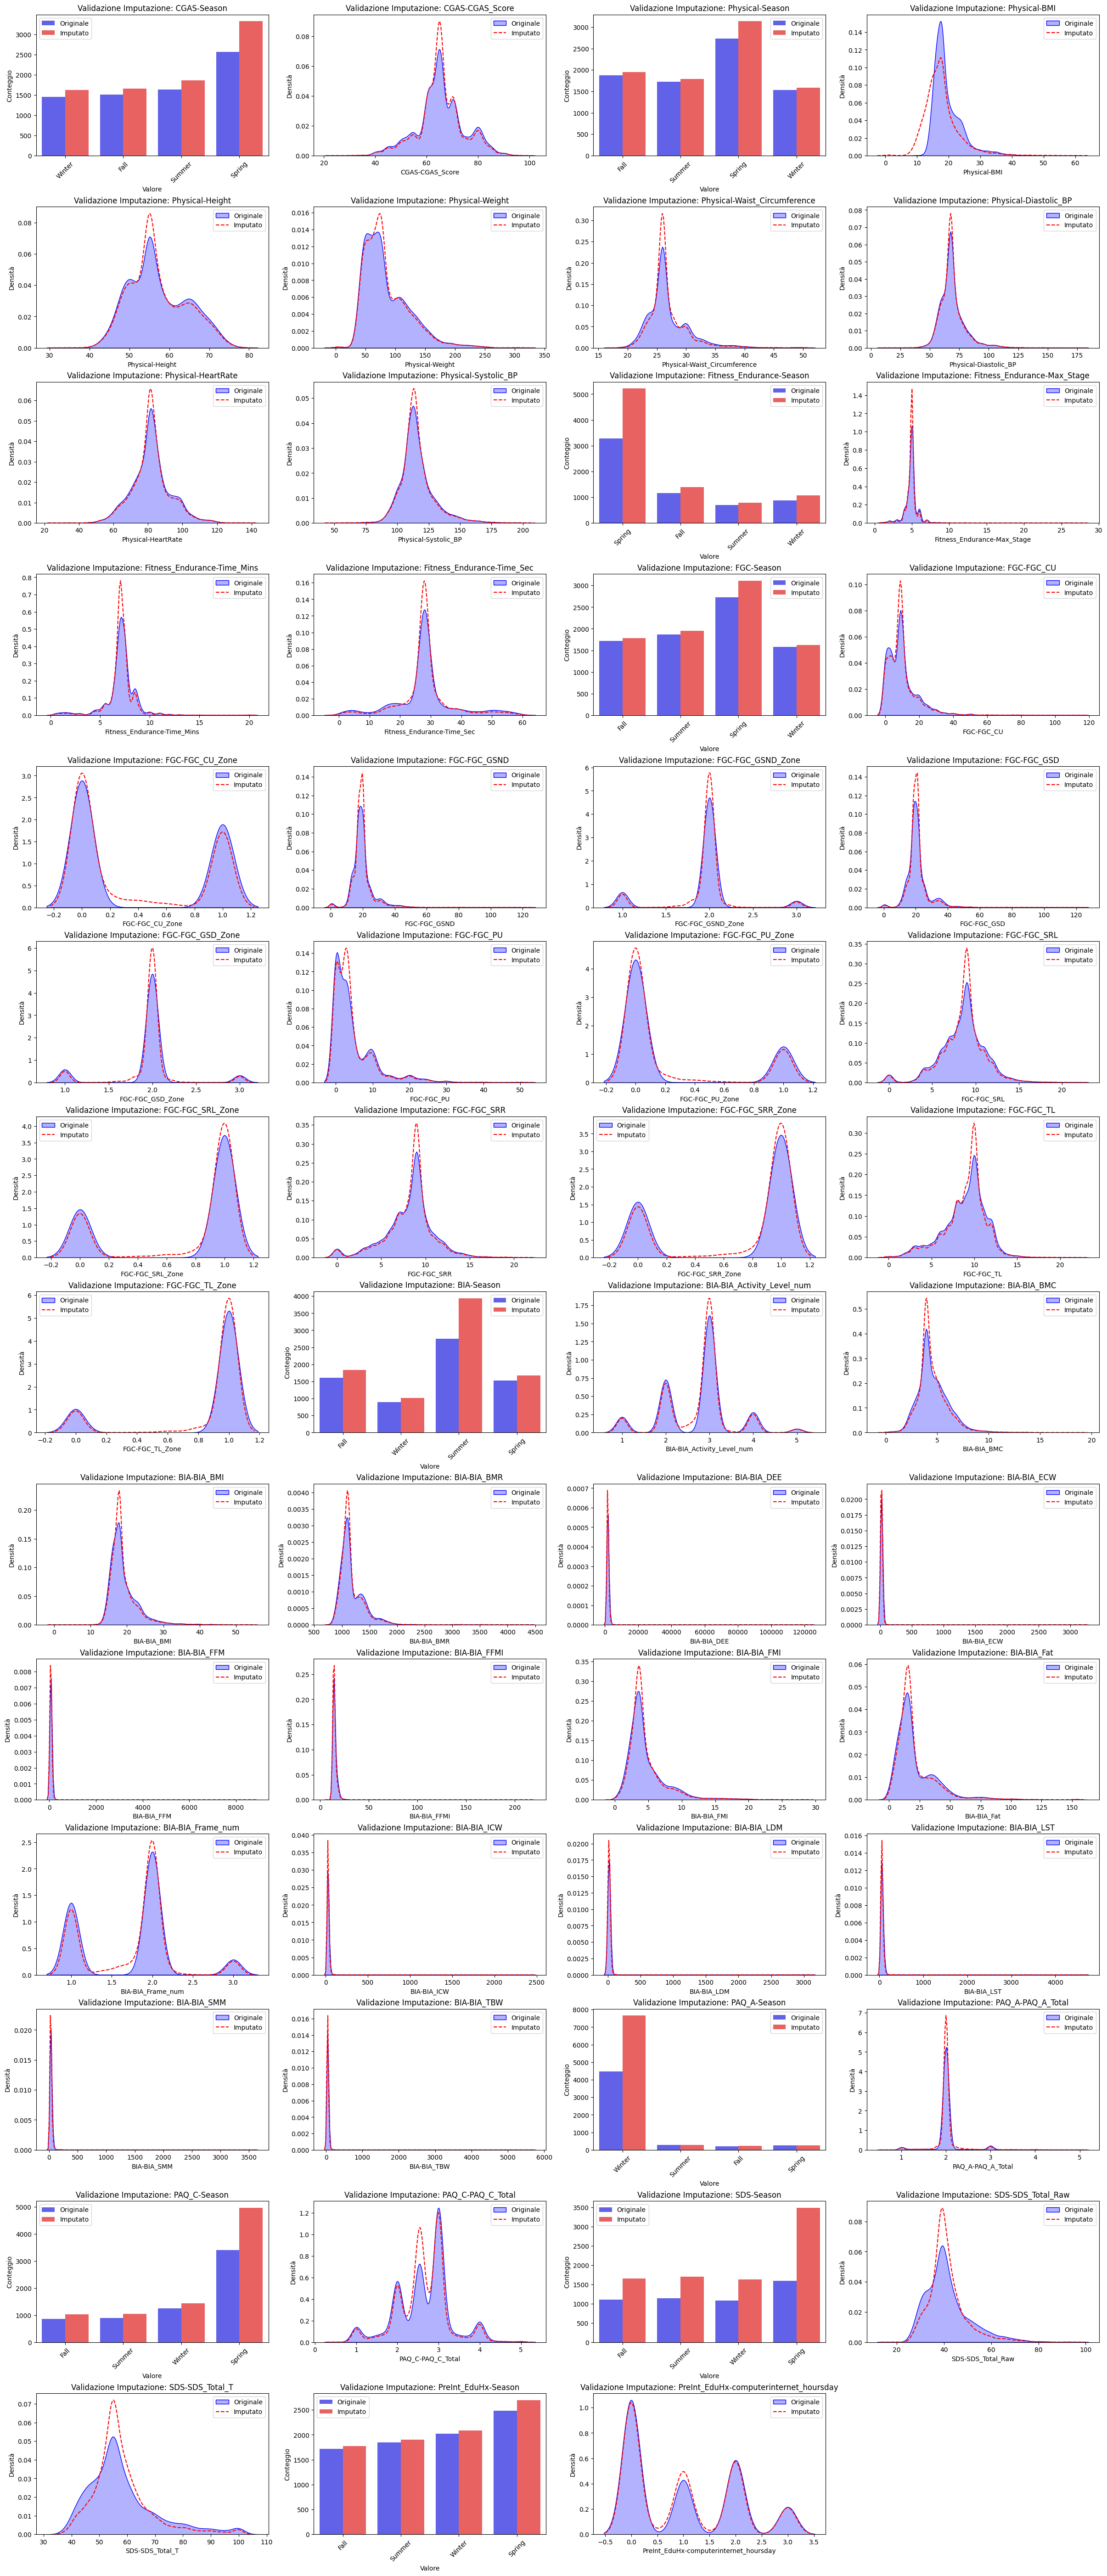

In [52]:


cols_with_nan = [col for col in df.columns if df[col].isnull().any()]
plt.figure(figsize=(8, 10))
ncols = 4
nrows = int(np.ceil(len(cols_with_nan) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 4), constrained_layout=True)
axes = axes.flatten()

for idx, col in enumerate(cols_with_nan):
    ax = axes[idx]
    if dfp[col].dtype != 'object' and dfp[col].nunique() > 10:
        sns.kdeplot(df[col].dropna(), label='Originale', color='blue', fill=True, alpha=0.3, ax=ax)
        sns.kdeplot(dfp[col], label='Imputato', color='red', linestyle='--', ax=ax)
        ax.set_ylabel('Densità')
    else:
        df_comp = pd.DataFrame({
            'Valore': pd.concat([df[col].dropna(), dfp[col]]),
            'Tipo': ['Originale'] * len(df[col].dropna()) + ['Imputato'] * len(dfp)
        })
        sns.countplot(data=df_comp, x='Valore', hue='Tipo', palette=['blue', 'red'], alpha=0.7, ax=ax)
        ax.set_ylabel('Conteggio')
        for label in ax.get_xticklabels():
            label.set_rotation(45)

    ax.set_title(f'Validazione Imputazione: {col}')
    ax.legend()

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.show()

In [53]:
stats_comparison = []

for col in cols_with_nan:
    # CASO NUMERICO
    if dfp[col].dtype != 'object':
        m_pre = df[col].mean()
        m_post = dfp[col].mean()
        diff = abs(m_pre - m_post) / m_pre * 100
        stats_comparison.append({'Colonna': col, 'Tipo': 'Numerico', 'Metrica': 'Media', 'Pre': round(m_pre, 2), 'Post': round(m_post, 2), 'Diff %': round(diff, 4)})
    
    # CASO CATEGORICO
    else:
        mod_pre = df[col].mode()[0]
        mod_post = dfp[col].mode()[0]
        # Calcoliamo la frequenza della moda originale
        freq_pre = (df[col] == mod_pre).mean() * 100
        freq_post = (dfp[col] == mod_pre).mean() * 100
        diff = abs(freq_pre - freq_post)
        stats_comparison.append({'Colonna': col, 'Tipo': 'Categorico', 'Metrica': f'Freq. Moda ({mod_pre})', 'Pre': f"{round(freq_pre, 1)}%", 'Post': f"{round(freq_post, 1)}%", 'Diff %': round(diff, 4)})

df_stats = pd.DataFrame(stats_comparison)
print(df_stats)

                                   Colonna        Tipo              Metrica  \
0                              CGAS-Season  Categorico  Freq. Moda (Spring)   
1                          CGAS-CGAS_Score    Numerico                Media   
2                          Physical-Season  Categorico  Freq. Moda (Spring)   
3                             Physical-BMI    Numerico                Media   
4                          Physical-Height    Numerico                Media   
5                          Physical-Weight    Numerico                Media   
6             Physical-Waist_Circumference    Numerico                Media   
7                    Physical-Diastolic_BP    Numerico                Media   
8                       Physical-HeartRate    Numerico                Media   
9                     Physical-Systolic_BP    Numerico                Media   
10                Fitness_Endurance-Season  Categorico  Freq. Moda (Spring)   
11             Fitness_Endurance-Max_Stage    Numeri

In [54]:
#Aggiungo le colonne a cui fare una trasformazione logaritmica (quelle con distribuzione molto asimmetrica)
cols_to_log = ['Fitness_Endurance-Max_Stage','FGC-FGC_CU','FGC-FGC_GSND','BIA-BIA_DEE','BIA-BIA_ECW','BIA-BIA_FFM','BIA-BIA_FFMI','BIA-BIA_ICW','BIA-BIA_LDM','BIA-BIA_LST','BIA-BIA_SMM','BIA-BIA_TBW']

In [55]:
for col in cols_to_log:
    # Assicurati che non ci siano valori negativi prima di procedere
    if (df[col] < 0).any():
        print(f"Attenzione: la colonna {col} contiene valori negativi. Il logaritmo non è applicabile direttamente.")
    else:
        df[col] = np.log1p(df[col])

<Figure size 1200x1800 with 0 Axes>

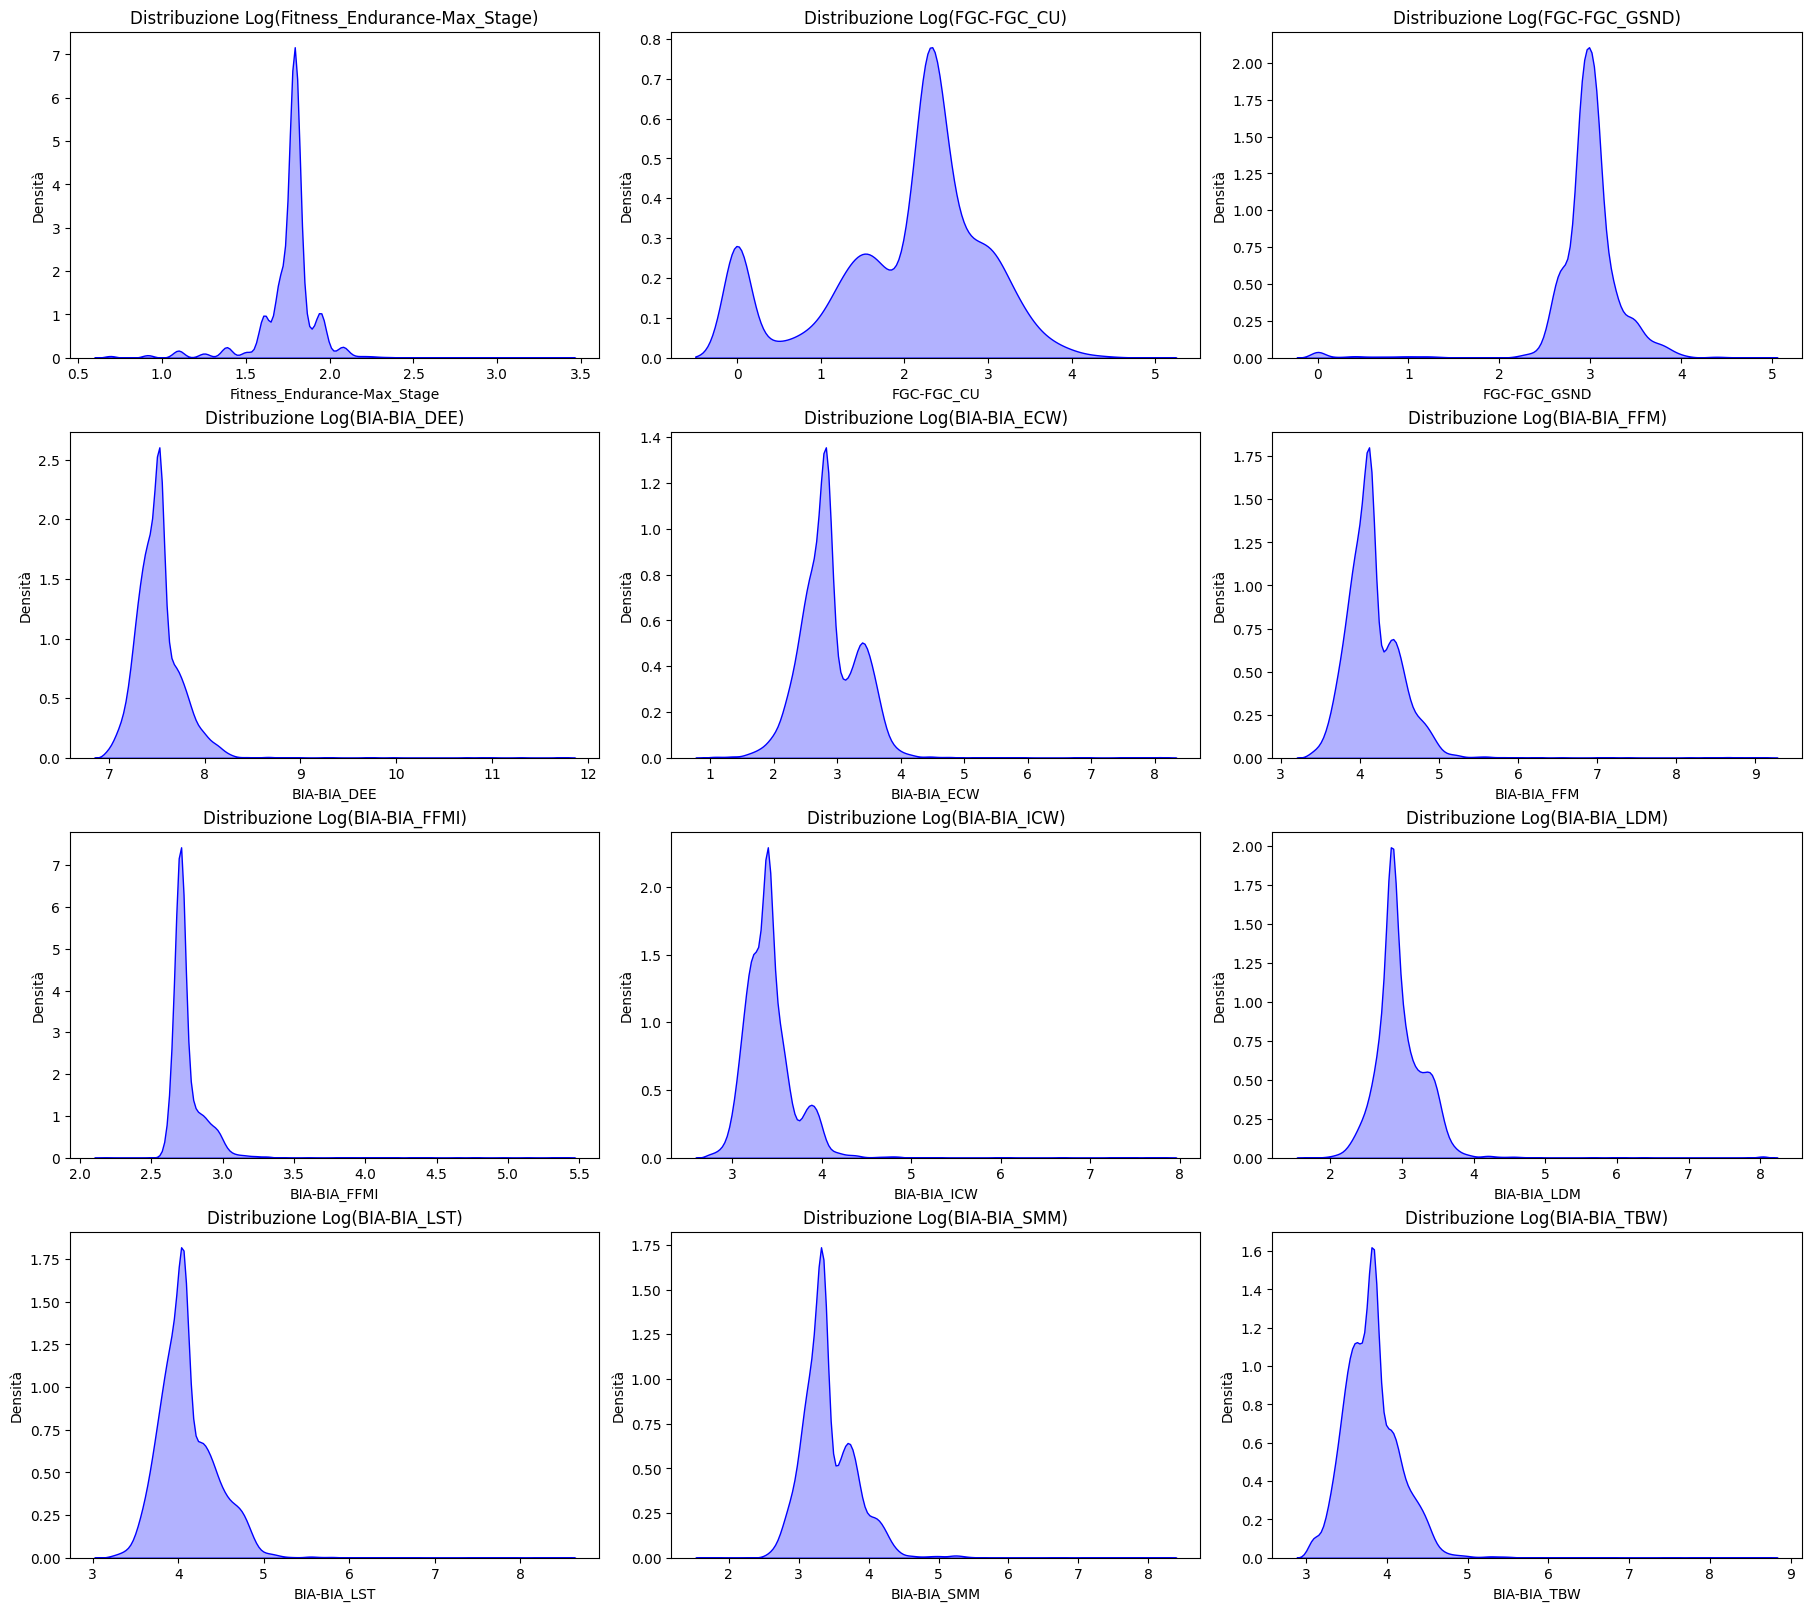

In [56]:
#controllo le distribuzioni dopo la trasformazione logaritmica usando un subplot
cols_to_log = ['Fitness_Endurance-Max_Stage','FGC-FGC_CU','FGC-FGC_GSND','BIA-BIA_DEE','BIA-BIA_ECW','BIA-BIA_FFM','BIA-BIA_FFMI','BIA-BIA_ICW','BIA-BIA_LDM','BIA-BIA_LST','BIA-BIA_SMM','BIA-BIA_TBW']
plt.figure(figsize=(12, 18))
ncols = 3
nrows = int(np.ceil(len(cols_to_log) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 4), constrained_layout=True)
for idx, col in enumerate(cols_to_log):
    ax = axes[idx // ncols, idx % ncols]
    sns.kdeplot(df[col], fill=True, color='blue', alpha=0.3, ax=ax)
    ax.set_title(f'Distribuzione Log({col})')
    ax.set_xlabel(col)
    ax.set_ylabel('Densità')
for j in range(idx + 1, len(axes.flatten())):
    fig.delaxes(axes.flatten()[j])  
plt.show()


In [57]:
#Inserisco le colonne dopo la trasformazione logaritmica nel dataframe dfp (sostituendo quelle originali)
for col in cols_to_log:
    dfp[col] = np.log1p(dfp[col])

In [58]:
#faccio round a 0 decimali per le colonne che non devono avere decimali: CGAS-CGAS_Score, FGC-FGC_CU_Zone, FGC-FGC_GSND_Zone,
#FGC-FGC_PU_Zone, FGC-FGC_SRL_Zone, FGC-FGC_SRR_Zone, FGC-FGC_TL_Zone, BIA-BIA_Activity_Level_num, BIA-BIA_Frame_num, SDS-SDS_Total_T, PreInt_EduHx-computerinternet_hoursday
cols_to_round_zero = ['CGAS-CGAS_Score', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND_Zone', 'FGC-FGC_PU_Zone', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR_Zone', 'FGC-FGC_TL_Zone', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_Frame_num', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday']
for col in cols_to_round_zero:
    dfp[col] = dfp[col].round(0).astype(int)

In [59]:
#Converto il dataset dfp in csv
dfp.to_csv('cmi_internet_pulito.csv', index=False)


In [60]:
new_df = pd.read_csv('cmi_internet_pulito.csv')

In [61]:
#Droppo tutte le colonne Season
season_cols = [col for col in new_df.columns if 'Season' in col]
new_df_corr = new_df.drop(columns=season_cols)

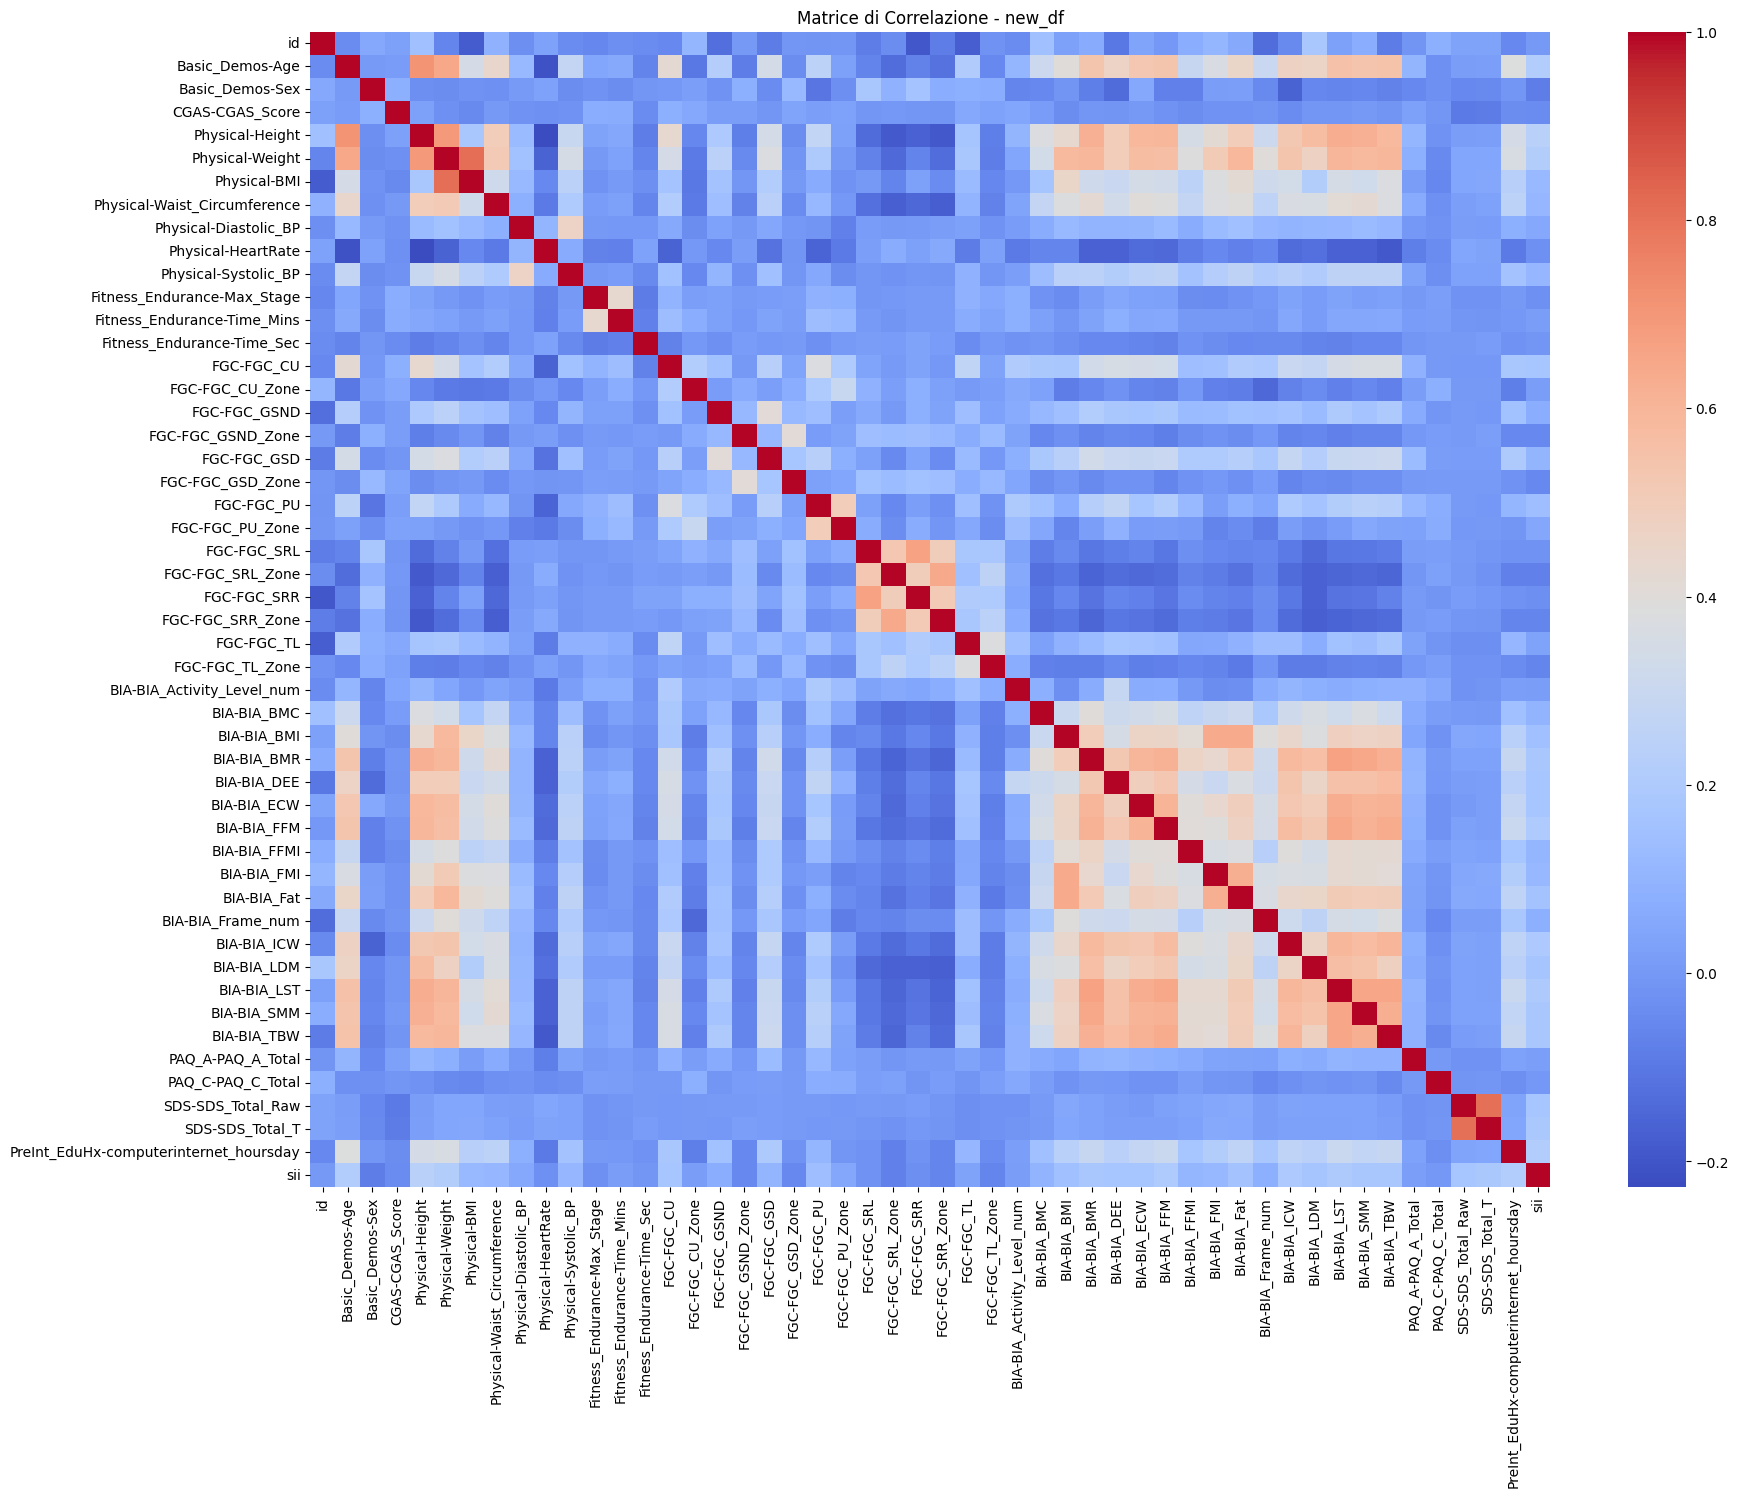

In [62]:
#Matrice delle correlazioni di new_df
plt.figure(figsize=(20, 15))
sns.heatmap(new_df_corr.corr(), fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Matrice di Correlazione - new_df')
plt.show()

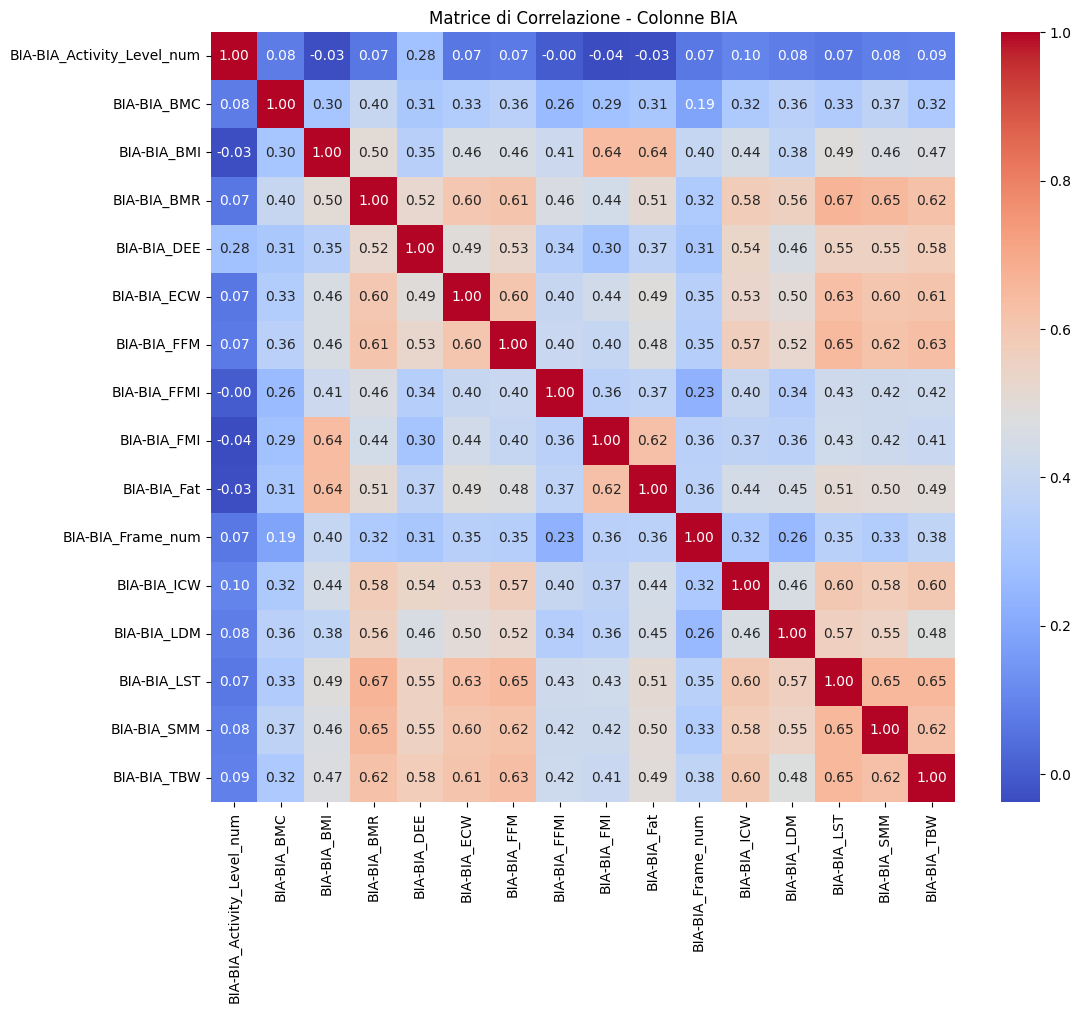

In [63]:
#considero solo le colonne BIA e faccio le matrici di correlazione
bia_cols = [col for col in new_df_corr.columns if col.startswith('BIA')]
new_df_bia = new_df_corr[bia_cols]
plt.figure(figsize=(12, 10))
sns.heatmap(new_df_bia.corr(), annot = True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Matrice di Correlazione - Colonne BIA')
plt.show()
